In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.decomposition import PCA
from statsmodels.stats.diagnostic import het_white
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import shapiro, kstest


In [ ]:
# Load dataset
file_path = "/metaverse_transactions_dataset.xlsx"
df = pd.read_excel(file_path, sheet_name='metaverse_transactions_data (2)')


In [ ]:
# Exploratory Data Analysis (EDA)
print("Dataset Summary:")
print(df.info())
print(df.describe())


Dataset Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78600 entries, 0 to 78599
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   timestamp          78600 non-null  datetime64[ns]
 1   hour_of_day        78600 non-null  int64         
 2   sending_address    78600 non-null  object        
 3   receiving_address  78600 non-null  object        
 4   amount             78600 non-null  float64       
 5   transaction_type   78600 non-null  object        
 6   location_region    78600 non-null  object        
 7   ip_prefix          78600 non-null  float64       
 8   login_frequency    78600 non-null  int64         
 9   session_duration   78600 non-null  int64         
 10  purchase_pattern   78600 non-null  object        
 11  age_group          78600 non-null  object        
 12  risk_score         78600 non-null  float64       
 13  anomaly            78600 non-null  object   


Missing Values:
timestamp            0
hour_of_day          0
sending_address      0
receiving_address    0
amount               0
transaction_type     0
location_region      0
ip_prefix            0
login_frequency      0
session_duration     0
purchase_pattern     0
age_group            0
risk_score           0
anomaly              0
dtype: int64


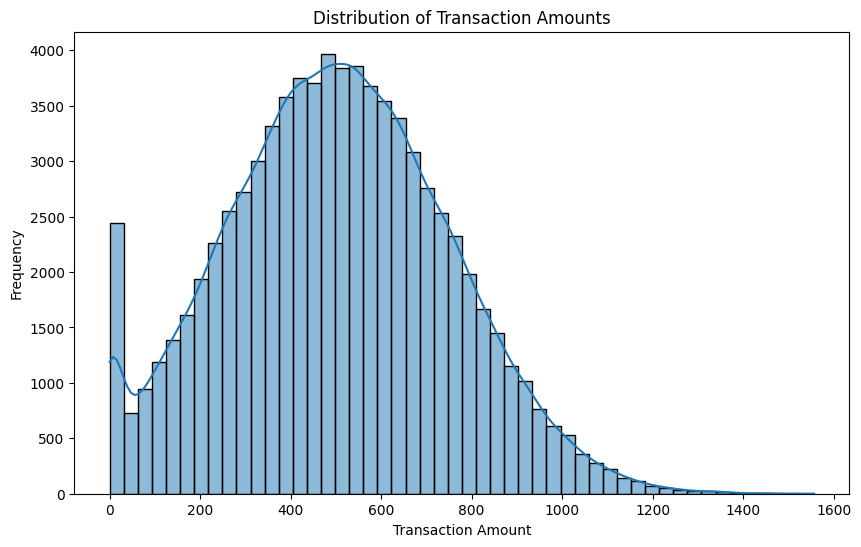

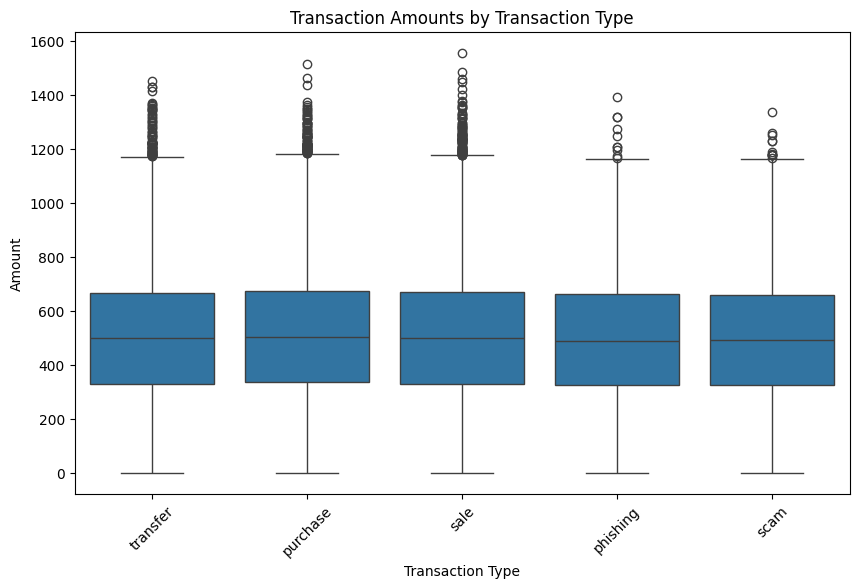

In [ ]:
# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Distribution of Transaction Amounts
plt.figure(figsize=(10, 6))
sns.histplot(df['amount'], bins=50, kde=True)
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.show()

# Boxplot of Transaction Amount by Transaction Type
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['transaction_type'], y=df['amount'])
plt.title('Transaction Amounts by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Amount')
plt.xticks(rotation=45)
plt.show()


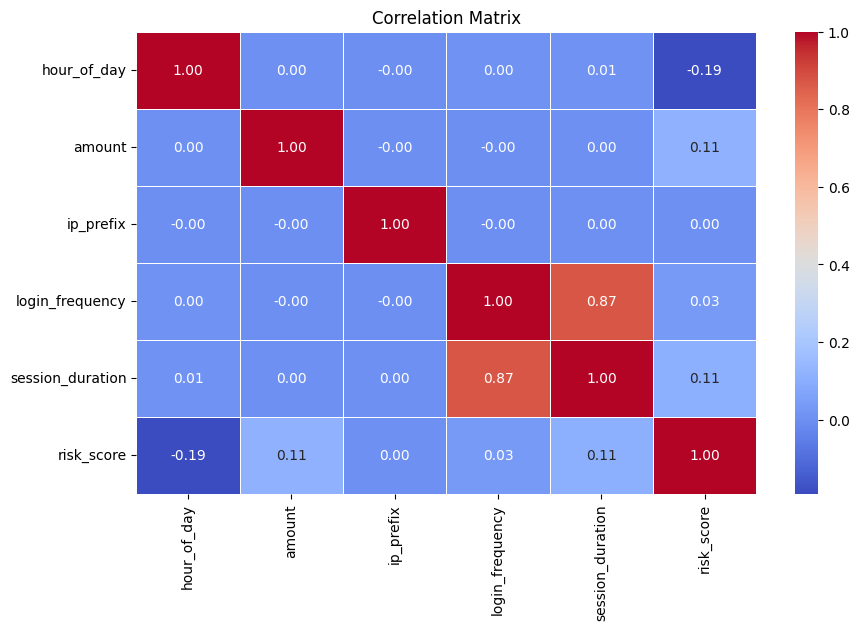

In [ ]:
# Correlation Matrix
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()


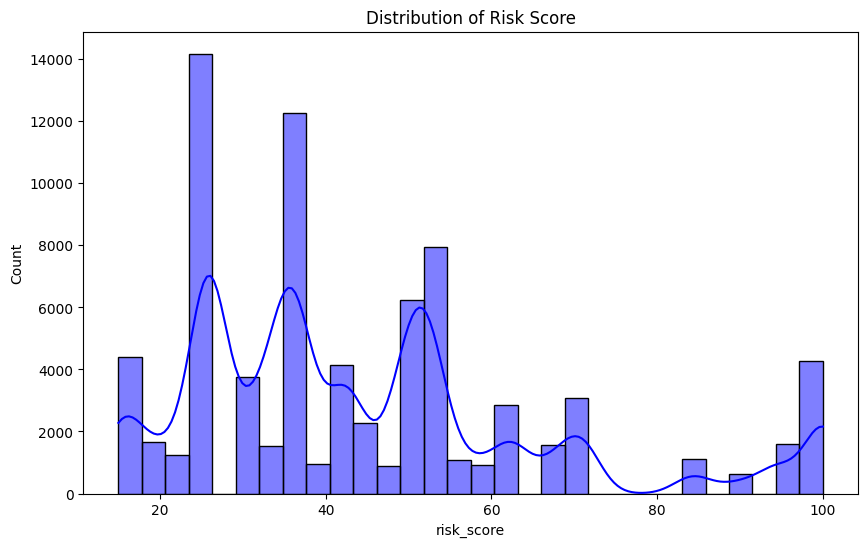

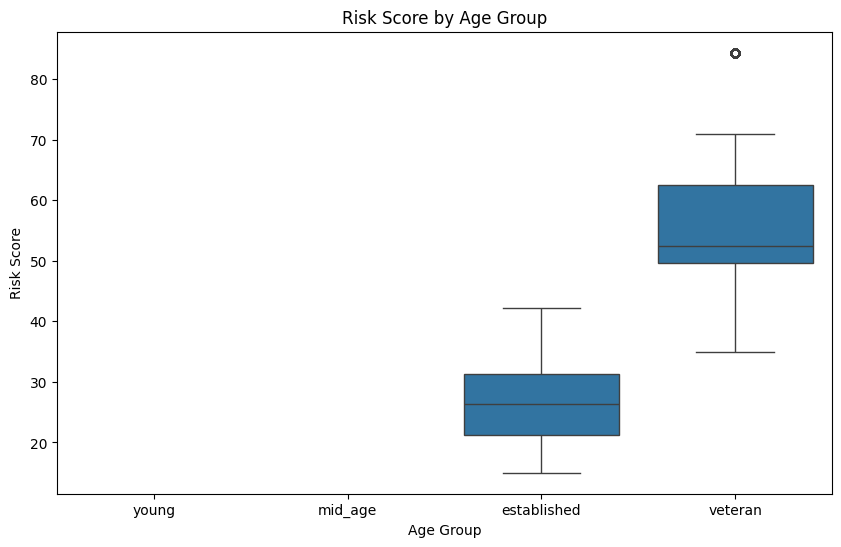

In [ ]:
# Distribution of Risk Score
plt.figure(figsize=(10, 6))
sns.histplot(df['risk_score'], bins=30, kde=True, color='blue')
plt.title("Distribution of Risk Score")
plt.show()

# Boxplot of Risk Score by Age Group
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['age_group'], y=df['risk_score'], order=['young', 'mid_age', 'established', 'veteran'])
plt.title('Risk Score by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Risk Score')
plt.show()


In [ ]:
# Feature Selection
numerical_features = ["hour_of_day", "amount", "ip_prefix", "login_frequency", "session_duration"]
categorical_features = ["transaction_type", "location_region", "purchase_pattern", "age_group"]




In [ ]:
# One-hot Encoding
encoder = OneHotEncoder(drop="first", sparse_output=False)
encoded_cats = encoder.fit_transform(df[categorical_features])
encoded_cats_df = pd.DataFrame(encoded_cats, columns=encoder.get_feature_names_out(categorical_features))

In [ ]:
# Standardize Numerical Features
scaler = StandardScaler()
scaled_numericals = scaler.fit_transform(df[numerical_features])
scaled_numericals_df = pd.DataFrame(scaled_numericals, columns=numerical_features)



In [ ]:
# Combine Features
X = pd.concat([scaled_numericals_df, encoded_cats_df], axis=1)
y = np.log(df["risk_score"] + 1)  # Log transformation applied to risk_score



In [ ]:
# Train-test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [ ]:
# Multiple Regression Model
X_train_sm = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train_sm).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             risk_score   R-squared:                       0.952
Model:                            OLS   Adj. R-squared:                  0.952
Method:                 Least Squares   F-statistic:                 8.315e+04
Date:                Sun, 08 Jun 2025   Prob (F-statistic):               0.00
Time:                        06:41:35   Log-Likelihood:                 55145.
No. Observations:               62880   AIC:                        -1.103e+05
Df Residuals:                   62864   BIC:                        -1.101e+05
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

In [ ]:
# Check for Multicollinearity
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
print("\nVariance Inflation Factors (VIF):")
print(vif_data)


/usr/local/lib/python3.11/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)



Variance Inflation Factors (VIF):
                          Feature        VIF
0                     hour_of_day   1.000256
1                          amount   1.000196
2                       ip_prefix   1.000310
3                 login_frequency  10.654626
4                session_duration   6.900248
5       transaction_type_purchase   2.308074
6           transaction_type_sale   4.653145
7           transaction_type_scam   1.466803
8       transaction_type_transfer   2.739185
9            location_region_Asia   1.908934
10         location_region_Europe   1.907406
11  location_region_North America   1.906982
12  location_region_South America   1.893171
13    purchase_pattern_high_value        inf
14        purchase_pattern_random        inf
15                  age_group_new        inf
16              age_group_veteran        inf


In [ ]:
# Apply PCA to Reduce Multicollinearity
pca = PCA(n_components=X_train.shape[1])  # Keep all components initially
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)


In [ ]:
# Select number of principal components that explain 95% variance
explained_variance_ratio = pca.explained_variance_ratio_.cumsum()
n_components = (explained_variance_ratio < 0.95).sum() + 1
X_train_pca = X_train_pca[:, :n_components]
X_test_pca = X_test_pca[:, :n_components]


In [ ]:
# Convert PCA output to DataFrame
X_train_pca_df = pd.DataFrame(X_train_pca, index=X_train.index) # Align index with original X_train
X_test_pca_df = pd.DataFrame(X_test_pca, index=X_test.index)  # Align index with original X_test


In [ ]:
# Check for Multicollinearity after PCA
vif_data_pca = pd.DataFrame()
vif_data_pca["Feature"] = [f"PC{i+1}" for i in range(n_components)]
vif_data_pca["VIF"] = [variance_inflation_factor(X_train_pca, i) for i in range(n_components)]
print("\nVariance Inflation Factors (VIF) after PCA:")
print(vif_data_pca)



Variance Inflation Factors (VIF) after PCA:
  Feature  VIF
0     PC1  1.0
1     PC2  1.0
2     PC3  1.0
3     PC4  1.0
4     PC5  1.0
5     PC6  1.0
6     PC7  1.0
7     PC8  1.0
8     PC9  1.0


In [ ]:
# Add constant to PCA-transformed training data
X_train_pca_sm = sm.add_constant(X_train_pca_df)

# Fit OLS regression on PCA components
model_pca = sm.OLS(y_train, X_train_pca_sm).fit()
print(model_pca.summary())

# Get residuals from the PCA regression
residuals = model_pca.resid


                            OLS Regression Results                            
Dep. Variable:             risk_score   R-squared:                       0.626
Model:                            OLS   Adj. R-squared:                  0.626
Method:                 Least Squares   F-statistic:                 1.169e+04
Date:                Sun, 08 Jun 2025   Prob (F-statistic):               0.00
Time:                        07:12:43   Log-Likelihood:                -9411.0
No. Observations:               62880   AIC:                         1.884e+04
Df Residuals:                   62870   BIC:                         1.893e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.7246      0.001   3323.104      0.0

In [ ]:
# Perform White's test for heteroscedasticity
white_test = het_white(residuals, X_train_pca_sm)

# Extract and print test statistics
lm_stat = white_test[0]
lm_pvalue = white_test[1]
f_stat = white_test[2]
f_pvalue = white_test[3]

print("\nWhite's Test for Heteroscedasticity:")
print(f"LM Statistic: {lm_stat:.4f}")
print(f"LM p-value: {lm_pvalue:.4f}")
print(f"F-Statistic: {f_stat:.4f}")
print(f"F-test p-value: {f_pvalue:.4f}")

# Interpretation
if lm_pvalue < 0.05:
    print("=> Evidence of heteroscedasticity (reject H0 of homoscedasticity).")
else:
    print("=> No evidence of heteroscedasticity (fail to reject H0).")



White's Test for Heteroscedasticity:
LM Statistic: 55003.4983
LM p-value: 0.0000
F-Statistic: 8124.4819
F-test p-value: 0.0000
=> Evidence of heteroscedasticity (reject H0 of homoscedasticity).


In [ ]:
# Use White's robust standard errors (HC3 is commonly recommended)
model_pca_robust = model_pca.get_robustcov_results(cov_type='HC3')

# Print the summary with robust SE
print(model_pca_robust.summary())


                            OLS Regression Results                            
Dep. Variable:             risk_score   R-squared:                       0.626
Model:                            OLS   Adj. R-squared:                  0.626
Method:                 Least Squares   F-statistic:                 2.596e+04
Date:                Sun, 08 Jun 2025   Prob (F-statistic):               0.00
Time:                        07:26:38   Log-Likelihood:                -9411.0
No. Observations:               62880   AIC:                         1.884e+04
Df Residuals:                   62870   BIC:                         1.893e+04
Df Model:                           9                                         
Covariance Type:                  HC3                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.7246      0.001   3322.860      0.0

In [ ]:
# Use Durbin-Watson Test to check Autocorrelation
dw_stat = durbin_watson(residuals)
print(f"Durbin-Watson statistic: {dw_stat:.4f}")

# Interpretation:
if dw_stat < 1.5:
    print("Possible positive autocorrelation.")
elif dw_stat > 2.5:
    print("Possible negative autocorrelation.")
else:
    print("Little to no autocorrelation detected.")



Durbin-Watson statistic: 1.9896
Little to no autocorrelation detected.


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 62880.
  res = hypotest_fun_out(*samples, **kwds)


Shapiro-Wilk Test statistic: 0.9218, p-value: 0.0000
Residuals are likely NOT normally distributed (reject H0).
KS Test statistic: 0.1162, p-value: 0.0000
Residuals are likely NOT normally distributed (reject H0).


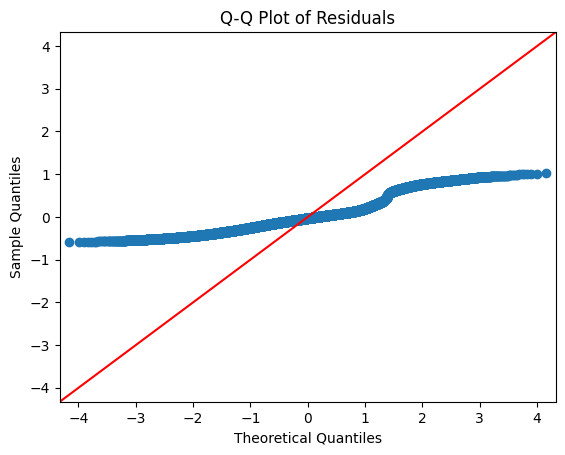

In [ ]:
# Shapiro-Wilk Test for Normality of residuals
stat, p_value = shapiro(residuals)
print(f"Shapiro-Wilk Test statistic: {stat:.4f}, p-value: {p_value:.4f}")

if p_value > 0.05:
    print("Residuals seem to be normally distributed (fail to reject H0).")
else:
    print("Residuals are likely NOT normally distributed (reject H0).")

# Kolmogorov-Smirnov Test (with normal distribution as reference)
# Standardize residuals first (mean=0, std=1)
residuals_std = (residuals - np.mean(residuals)) / np.std(residuals)

stat, p_value = kstest(residuals_std, 'norm')
print(f"KS Test statistic: {stat:.4f}, p-value: {p_value:.4f}")

if p_value > 0.05:
    print("Residuals seem to be normally distributed (fail to reject H0).")
else:
    print("Residuals are likely NOT normally distributed (reject H0).")

# Q-Q Plot (visual check for normality)
sm.qqplot(residuals, line='45')
plt.title("Q-Q Plot of Residuals")
plt.show()